<a href="https://colab.research.google.com/github/Jpablo179804/MineriaDatos/blob/main/Parcial3/Ejercicio_de_K-NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ejercicio de K-NN

Utiliza el dataset de las flores Iris.

Realiza una separación de conjunto de datos de entrenamiento y el de prueba, de la siguiente manera:

Entrenamiento 80%
Prueba 20%
Evalua la clasificación utilizando K-NN

Investiga que es el codo

Y determina el valor de k adecuaduado para clasificar las flores Iris

In [1]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#####¿Qué es el "Método del Codo"?

El método del codo es una técnica visual que se utiliza para determinar el número óptimo de vecinos ($k$) en el algoritmo K-NN (también se usa mucho en K-Means).Funciona de la siguiente manera:

1. Ejecutas el algoritmo K-NN varias veces, iterando sobre diferentes valores de $k$ (por ejemplo, del 1 al 20).

2. Para cada valor de $k$, calculas la tasa de error (qué porcentaje de las predicciones fueron incorrectas en tu conjunto de prueba).

3. Graficas estos valores: el eje X representa la $k$ y el eje Y representa la tasa de error.

4. Buscas el "codo" en la gráfica: el punto donde la tasa de error cae drásticamente y luego comienza a estabilizarse o a subir de nuevo. Ese punto de inflexión te indica el valor de $k$ que ofrece el mejor equilibrio: ni tan bajo como para sobreajustar el modelo (overfitting), ni tan alto como para perder precisión (underfitting).

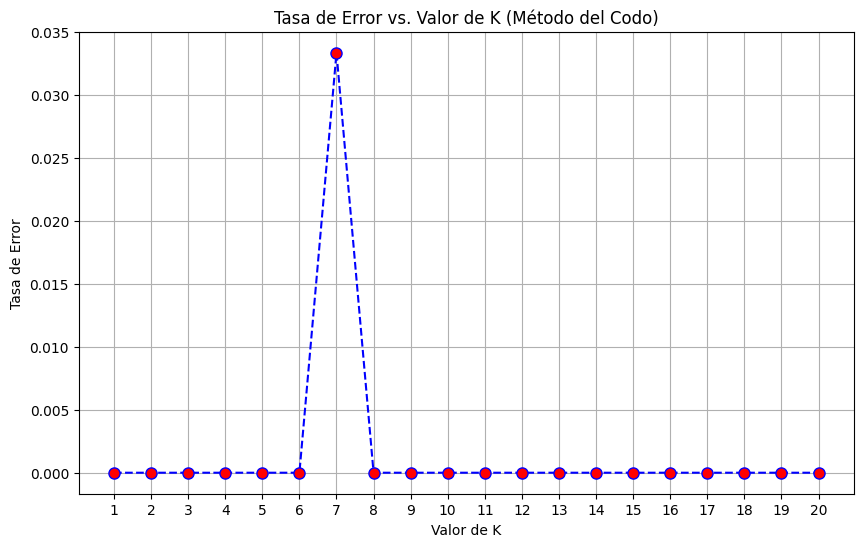


Entrenando con K = 3...

Precisión: 100.00%

Clasificación
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

K -> 3


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

iris = load_iris()
X = iris.data    #largo/ancho de sépalo y pétalo
y = iris.target  # 3 especies de flores

#80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Investigar el "Codo" para encontrar el mejor valor de k
tasas_error = []

#k desde 1 hasta 20
rango_k = range(1, 21)
for i in rango_k:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)

    tasas_error.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10, 6))
plt.plot(rango_k, tasas_error, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Tasa de Error vs. Valor de K (Método del Codo)')
plt.xlabel('Valor de K')
plt.ylabel('Tasa de Error')
plt.xticks(rango_k)
plt.grid(True)
plt.show()

k_optimo = 3

print(f"\nEntrenando con K = {k_optimo}...\n")
knn_optimo = KNeighborsClassifier(n_neighbors=k_optimo)
knn_optimo.fit(X_train, y_train)
predicciones = knn_optimo.predict(X_test)

print(f"Precisión: {accuracy_score(y_test, predicciones) * 100:.2f}%")
print("\nClasificación")
print(classification_report(y_test, predicciones, target_names=iris.target_names))

print("K -> 3")